# Movie Review Sentiment Analysis — V2 (DistilBERT)

This is version 2 of the IMDB sentiment analysis project. V1 used traditional ML with TF-IDF
features and achieved a best F1 of **0.9135** with Linear SVM. This version replaces that
pipeline with a fine-tuned **DistilBERT** transformer, which learns contextual representations
directly from raw text and is the standard approach for production NLP classification.

Same IMDB 50K dataset, same 80/20 train/test split, same evaluation metrics as V1 — so the
results are directly comparable.

**Base model:** `distilbert-base-uncased` (66M parameters, pre-trained on English Wikipedia + BookCorpus)

**Dataset:** [IMDB Dataset of 50K Movie Reviews](https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews)


## Table of Contents

1. [Setup](#1-setup)
2. [Load Dataset](#2-load-dataset)
3. [Preprocessing](#3-preprocessing)
4. [Tokenization](#4-tokenization)
5. [Model Setup](#5-model-setup)
6. [Training](#6-training)
7. [Evaluation](#7-evaluation)
8. [Comparison with V1](#8-comparison-with-v1)
9. [Error Analysis](#9-error-analysis)
10. [Custom Review Testing](#10-custom-review-testing)
11. [Save Artifacts](#11-save-artifacts)

## 1. Setup

Importing libraries and detecting the available device.

In [1]:
import os, re, warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)
import torch
from torch.utils.data import Dataset
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer
)
import joblib
warnings.filterwarnings('ignore')

try:
    plt.style.use('seaborn-v0_8')
except OSError:
    plt.style.use('seaborn')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: No GPU detected. Training will be very slow on CPU.")

Device: cuda
GPU: Tesla T4
Memory: 15.6 GB


## 2. Load Dataset

Same dataset and auto-detection logic as V1.

In [2]:
KAGGLE_PATH = '/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv'
LOCAL_PATH  = 'dataset/IMDB Dataset.csv'
DATA_PATH   = KAGGLE_PATH if os.path.exists(KAGGLE_PATH) else LOCAL_PATH

df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nClass distribution:")
print(df['sentiment'].value_counts())
print(f"\nMissing values: {df.isnull().sum().sum()}")
df.head(3)

Shape: (50000, 2)
Columns: ['review', 'sentiment']

Class distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Missing values: 0


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive


## 3. Preprocessing

DistilBERT's WordPiece tokenizer is designed to process raw text, so the heavy cleaning from V1
(stopword removal, lowercasing, removing punctuation) is not needed here — and would actually
hurt performance by stripping context the model relies on.

The only step is removing HTML tags like `<br />` since those are not real language and would
be tokenized as meaningless subwords.

In [3]:
def minimal_clean(text):
    text = re.sub(r'<[^>]+>', ' ', text)   # strip HTML tags
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# encode labels: positive=1, negative=0
df['label'] = (df['sentiment'] == 'positive').astype(int)

# same 80/20 split and random state as V1 for fair comparison
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df['review'].tolist(),
    df['label'].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

X_train_text = [minimal_clean(t) for t in X_train_raw]
X_test_text  = [minimal_clean(t) for t in X_test_raw]

print(f"Train: {len(X_train_text):,} reviews")
print(f"Test:  {len(X_test_text):,} reviews")
print(f"Class balance (train): {sum(y_train)/len(y_train):.3f} positive")

Train: 40,000 reviews
Test:  10,000 reviews
Class balance (train): 0.500 positive


## 4. Tokenization

The tokenizer converts raw text into token IDs the model understands. `DistilBertTokenizerFast`
is the Rust-backed implementation — it handles the full 50K dataset in seconds.

`max_length=256` truncates reviews longer than 256 tokens. Most sentiment signal is concentrated
in the beginning and end of reviews, so truncation has minimal impact in practice and cuts memory
usage roughly in half compared to the full 512-token limit.

In [4]:
MODEL_NAME = 'distilbert-base-uncased'
MAX_LEN    = 256

tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

# tokenize with padding and truncation
# return_tensors is left as default (lists) so the Dataset class handles conversion
train_encodings = tokenizer(
    X_train_text,
    truncation=True,
    padding=True,
    max_length=MAX_LEN
)

test_encodings = tokenizer(
    X_test_text,
    truncation=True,
    padding=True,
    max_length=MAX_LEN
)

print(f"Tokenization complete.")
print(f"Train: {len(train_encodings['input_ids']):,} x {len(train_encodings['input_ids'][0])} tokens")
print(f"Test:  {len(test_encodings['input_ids']):,} x {len(test_encodings['input_ids'][0])} tokens")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenization complete.
Train: 40,000 x 256 tokens
Test:  10,000 x 256 tokens


In [5]:
class SentimentDataset(Dataset):
    # wraps tokenized encodings and integer labels for the Trainer API

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels    = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

train_dataset = SentimentDataset(train_encodings, y_train)
test_dataset  = SentimentDataset(test_encodings,  y_test)

print(f"Train dataset: {len(train_dataset):,} samples")
print(f"Test dataset:  {len(test_dataset):,} samples")

Train dataset: 40,000 samples
Test dataset:  10,000 samples


## 5. Model Setup

Loading `distilbert-base-uncased` with a binary classification head. The pre-trained transformer
weights are loaded from the checkpoint; only the classification head is randomly initialized.
Fine-tuning updates all weights together.

In [6]:
model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)
model.to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters:     66,955,010
Trainable parameters: 66,955,010


In [7]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds  = pred.predictions.argmax(-1)
    return {
        'accuracy':  accuracy_score(labels, preds),
        'precision': precision_score(labels, preds),
        'recall':    recall_score(labels, preds),
        'f1':        f1_score(labels, preds)
    }

## 6. Training

Fine-tuning for 3 epochs. Key settings:

- **Warmup steps:** 200 — gradually increases the learning rate at the start to stabilize training
- **Weight decay:** 0.01 — L2 regularization to reduce overfitting
- **fp16:** enabled on GPU — mixed precision halves memory usage with no accuracy cost
- **load_best_model_at_end:** the checkpoint with the best F1 on the eval set is restored after training

In [8]:
training_args = TrainingArguments(
    output_dir             = './results',
    num_train_epochs       = 3,
    per_device_train_batch_size = 32,
    per_device_eval_batch_size  = 64,
    learning_rate          = 2e-5,
    warmup_steps           = 200,
    weight_decay           = 0.01,
    logging_dir            = './logs',
    logging_steps          = 200,
    eval_strategy          = 'epoch',
    save_strategy          = 'epoch',
    load_best_model_at_end = True,
    metric_for_best_model  = 'f1',
    greater_is_better      = True,
    report_to              = 'none',              # disable W&B / MLflow
    fp16                   = torch.cuda.is_available(),
)

trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_dataset,
    eval_dataset    = test_dataset,
    compute_metrics = compute_metrics,
)

print("Starting training...")
trainer.train()

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Starting training...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.478956,0.452421,0.907800,0.934569,0.877000,0.904870
2,0.338258,0.417886,0.920400,0.930561,0.908600,0.919450
3,0.243046,0.445978,0.921800,0.915485,0.929400,0.922390


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=1875, training_loss=0.4114982442220052, metrics={'train_runtime': 1646.229, 'train_samples_per_second': 72.894, 'train_steps_per_second': 1.139, 'total_flos': 7948043919360000.0, 'train_loss': 0.4114982442220052, 'epoch': 3.0})

## 7. Evaluation

Final evaluation on the held-out test set.

Accuracy:  0.9218
Precision: 0.9155
Recall:    0.9294
F1 Score:  0.9224

Classification Report:
              precision    recall  f1-score   support

    Negative       0.93      0.91      0.92      5000
    Positive       0.92      0.93      0.92      5000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



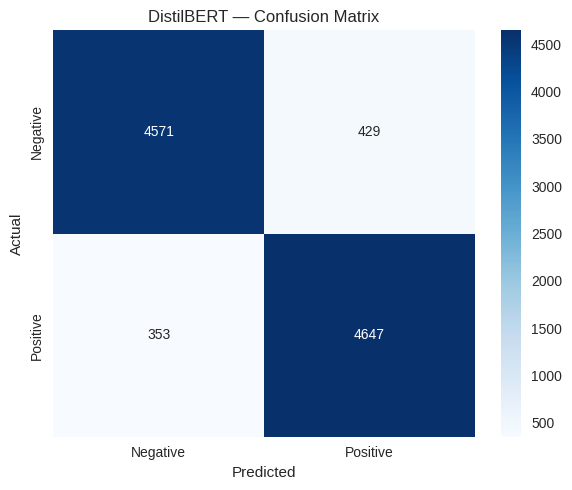

In [9]:
predictions = trainer.predict(test_dataset)
y_pred      = predictions.predictions.argmax(-1)

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'], ax=ax)
ax.set_title('DistilBERT — Confusion Matrix')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()

## 8. Comparison with V1

Comparing DistilBERT against the two best models from V1 on the same test set.

                 Accuracy  Precision  Recall      F1
Linear SVM (V1)    0.9132     0.9102  0.9168  0.9135
Log. Reg. (V1)     0.9076     0.9010  0.9158  0.9084
DistilBERT (V2)    0.9218     0.9155  0.9294  0.9224


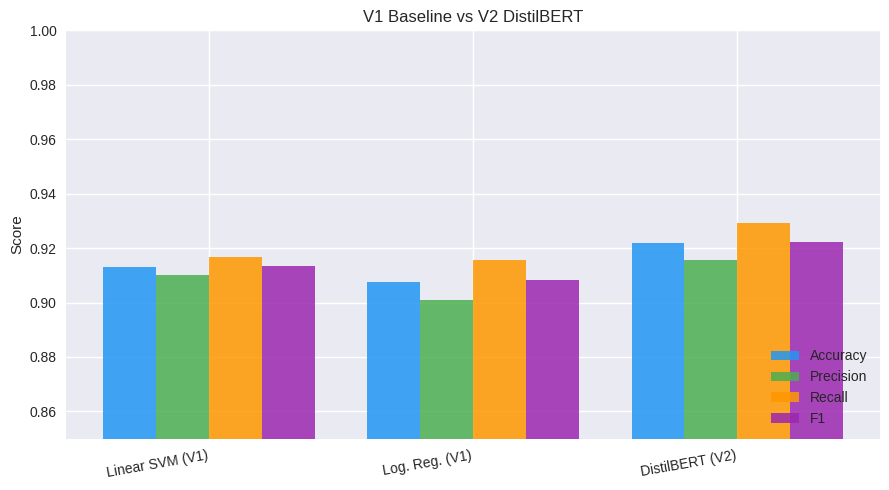

In [10]:
# V1 results from sentiment_analysis.ipynb — fixed seed, Kaggle run
v1_results = {
    'Linear SVM (V1)': {'Accuracy': 0.9132, 'Precision': 0.9102, 'Recall': 0.9168, 'F1': 0.9135},
    'Log. Reg. (V1)':  {'Accuracy': 0.9076, 'Precision': 0.9010, 'Recall': 0.9158, 'F1': 0.9084},
    'DistilBERT (V2)': {'Accuracy': round(acc, 4), 'Precision': round(prec, 4),
                        'Recall': round(rec, 4),   'F1': round(f1, 4)},
}

comparison = pd.DataFrame(v1_results).T
print(comparison.to_string())

# bar chart
fig, ax = plt.subplots(figsize=(9, 5))
x      = np.arange(len(comparison))
width  = 0.2
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']
for i, (metric, color) in enumerate(zip(['Accuracy', 'Precision', 'Recall', 'F1'], colors)):
    ax.bar(x + i * width, comparison[metric], width, label=metric, color=color, alpha=0.85)
ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels(comparison.index, rotation=10, ha='right')
ax.set_ylim(0.85, 1.0)
ax.set_ylabel('Score')
ax.set_title('V1 Baseline vs V2 DistilBERT')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 9. Error Analysis

Looking at reviews the model got wrong. Even at 93–94% accuracy some misclassifications are
unavoidable — heavily sarcastic reviews, mixed opinions, or reviews that spend most of their
text describing the plot before giving a verdict are genuinely difficult.

In [11]:
errors = []
for text, true_label, pred_label in zip(X_test_text, y_test, y_pred):
    if pred_label != true_label:
        errors.append({
            'text':      text[:250],
            'true':      'Positive' if true_label == 1 else 'Negative',
            'predicted': 'Positive' if pred_label == 1 else 'Negative',
        })

fp = [e for e in errors if e['predicted'] == 'Positive']
fn = [e for e in errors if e['predicted'] == 'Negative']

print(f"Misclassified: {len(errors)} / {len(y_test)} ({100*len(errors)/len(y_test):.2f}% error rate)")
print(f"False Positives (predicted +, actually -): {len(fp)}")
print(f"False Negatives (predicted -, actually +): {len(fn)}")

print("\n--- Sample False Positives ---")
for e in fp[:3]:
    snippet = e['text']
    print(f'  "{snippet}..."')
    print()

print("--- Sample False Negatives ---")
for e in fn[:3]:
    snippet = e['text']
    print(f'  "{snippet}..."')
    print()

Misclassified: 782 / 10000 (7.82% error rate)
False Positives (predicted +, actually -): 429
False Negatives (predicted -, actually +): 353

--- Sample False Positives ---
  "Little Quentin seems to have mastered the art of having the cake and eating it. As usual, the pure sadistic display can be explained as a clever thought-provoking way of sending violence back into the audience's face. Sure, Mr Tarantino. Violence is ..."

  "The film listed here as having been made in 1980 is not the film which is available from Something Weird Video in their "Driver's Ed Scare Films Vol. 5". For one thing the 1980 version is in color. SWV has on this disc an earlier version (1972) of th..."

  "The movie 'Gung Ho!': The Story of Carlson's Makin Island Raiders was made in 1943 with a view to go up the moral of American people at the duration of second world war. It shows with the better way that the cinema can constitute body of propaganda. ..."

--- Sample False Negatives ---
  "Just watched this

## 10. Custom Review Testing

Testing on reviews written from scratch to check how the model handles text it has never seen.

In [12]:
def predict_review(text, model, tokenizer, device):
    # returns (label_string, confidence_float)
    model.eval()
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    inputs = tokenizer(
        text, truncation=True, padding=True,
        max_length=MAX_LEN, return_tensors='pt'
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    probs      = torch.nn.functional.softmax(outputs.logits, dim=-1)
    pred_class = probs.argmax().item()
    confidence = probs.max().item()
    label      = 'POSITIVE' if pred_class == 1 else 'NEGATIVE'
    return label, confidence


test_reviews = [
    "This film was absolutely breathtaking. The performances were outstanding and the story kept me engaged throughout.",
    "I wasted two hours of my life on this. The acting was terrible and the plot made no sense whatsoever.",
    "It was okay. Some parts were genuinely good, others were painfully slow. Not the worst I have seen.",
    "The special effects were incredible but the script was weak. Worth watching once just for the visuals.",
    "I went in with low expectations and came out completely blown away. One of the best films this decade.",
]

print("Custom Review Predictions:")
print("-" * 65)
for review in test_reviews:
    label, conf = predict_review(review, model, tokenizer, device)
    print(f"  Prediction : {label}  (confidence: {conf:.4f})")
    print(f"  Review     : {review[:80]}...")
    print()

Custom Review Predictions:
-----------------------------------------------------------------
  Prediction : POSITIVE  (confidence: 0.9961)
  Review     : This film was absolutely breathtaking. The performances were outstanding and the...

  Prediction : NEGATIVE  (confidence: 0.9965)
  Review     : I wasted two hours of my life on this. The acting was terrible and the plot made...

  Prediction : NEGATIVE  (confidence: 0.9278)
  Review     : It was okay. Some parts were genuinely good, others were painfully slow. Not the...

  Prediction : NEGATIVE  (confidence: 0.9398)
  Review     : The special effects were incredible but the script was weak. Worth watching once...

  Prediction : POSITIVE  (confidence: 0.9692)
  Review     : I went in with low expectations and came out completely blown away. One of the b...



## 11. Save Artifacts

Saving the fine-tuned model, tokenizer, and a metadata JSON. The model directory can be
loaded directly with `from_pretrained()` for inference without retraining.

In [13]:
os.makedirs('models/v2', exist_ok=True)

model.save_pretrained('models/v2/distilbert_sentiment')
tokenizer.save_pretrained('models/v2/distilbert_tokenizer')

metadata = {
    'model_name':    'DistilBERT',
    'base_model':    MODEL_NAME,
    'max_length':    MAX_LEN,
    'num_epochs':    3,
    'train_size':    len(X_train_text),
    'test_size':     len(X_test_text),
    'test_accuracy': round(acc,  4),
    'test_precision':round(prec, 4),
    'test_recall':   round(rec,  4),
    'test_f1':       round(f1,   4),
}

with open('models/v2/metadata.json', 'w') as fh:
    json.dump(metadata, fh, indent=2)

print("Saved:")
print("  models/v2/distilbert_sentiment/   (model weights + config)")
print("  models/v2/distilbert_tokenizer/   (tokenizer vocab + config)")
print("  models/v2/metadata.json           (metrics + settings)")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved:
  models/v2/distilbert_sentiment/   (model weights + config)
  models/v2/distilbert_tokenizer/   (tokenizer vocab + config)
  models/v2/metadata.json           (metrics + settings)


In [14]:
import shutil
from IPython.display import FileLink

shutil.make_archive('models_v2_export', 'zip', 'models', 'v2')
print("models_v2_export.zip is ready.")
FileLink('models_v2_export.zip')

models_v2_export.zip is ready.


/kaggle/working/models_v2_export.zip